In [ ]:
from core import AnalysisConfig, Reference, ObsType
from utils import Analyzer, ResultsManager
from utils.workdirectory import WorkDirectory
from pathlib import Path
import pandas as pd

In [22]:
%config InlineBackend.figure_format = 'retina'

In [72]:
import numpy as np
import matplotlib.pyplot as plt
import mplhep

mplhep.style.use("CMS")
import matplotlib.patches as patches
from matplotlib.collections import LineCollection

def scatterplot_UL_by_type(df: pd.DataFrame, outfile):
    
    label_fontsize = 26
    tick_fontsize = 26
    cms_fontsize = 26
    
    # Create figure with CMS-like styling
    fig, ax = plt.subplots(figsize=(20, 12))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    
    x_positions = []
    y_values = []
    colors = []
    labels = []
    categories = []
    
    current_x = 1
    
    # Enhanced color palette
    type_mapping = {
        'llr_from_1D': ('Univariate LLR', '#e74c3c', '#c0392b'),
        'llr_from_2D': ('Bivariate LLR', '#3498db', '#2980b9'), 
        'llr_from_3D': ('Trivariate LLR', '#2ecc71', '#27ae60')
    }
    
    # Add continuous background regions - all exactly 1.0 unit wide, no gaps
    region_colors = ['#ffeaea', '#eaf4ff', '#eafff0']
    region_index = 0
    region_boundaries = []
    
    for obs_type, (label, color_main, color_dark) in type_mapping.items():
        subset = df[df['obs_type'] == obs_type]
        if not subset.empty:
            # All regions exactly 1.0 unit wide: center ± 0.5
            start_x = current_x - 0.5
            end_x = current_x + 0.5
            
            # Add subtle background coloring
            ax.axvspan(start_x, end_x, 
                      facecolor=region_colors[region_index], alpha=0.3, zorder=0)
            
            # Store boundary for dividing lines (except for first region)
            if current_x > 1:
                region_boundaries.append(start_x)
            
            region_index += 1
            
            # Create gradient effect with multiple layers
            x_jitter = np.random.normal(current_x, 0.08, len(subset))
            
            # Add glow effect (larger, more transparent points behind)
            ax.scatter(x_jitter, subset['mu'], c=color_main, s=120, alpha=0.3, 
                      edgecolors='none', zorder=1)
            
            # Main points with gradient coloring based on y-value
            scatter = ax.scatter(x_jitter, subset['mu'], c=subset['mu'], 
                               cmap='viridis', s=80, alpha=0.8,
                               edgecolors=color_dark, linewidth=1.2, zorder=3)
            
            x_positions.extend(x_jitter)
            y_values.extend(subset['mu'].tolist())  # Convert to list explicitly
            colors.extend([color_main] * len(subset))
            labels.append(label)
            categories.extend([label] * len(subset))
            current_x += 1
    
    # Enhanced multivariate section
    multivar_df = df[df['obs_type'] == 'llr_factorized']
    if not multivar_df.empty:
        n_var_values = sorted(multivar_df['n_variables'].unique())
        
        # Custom gradient colors for multivariate
        plasma_colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(n_var_values)))
        
        multivar_names = {
            2: '2', 3: '3', 4: '4', 5: '5',
            6: '6', 7: '7', 8: '8', 9: '9',
            10: '10', 11: '11', 12: '12', 13: '13',
            14: '14', 15: '15', 16: '16'
        }
        
        # Add individual background regions for each multivariate category
        multivar_region_colors = plt.cm.plasma(np.linspace(0.05, 0.15, len(n_var_values)))
        
        for i, n_vars in enumerate(n_var_values):
            # Individual background region for each multivariate category
            x_center = current_x + i
            start_x = x_center - 0.5
            end_x = x_center + 0.5
            ax.axvspan(start_x, end_x, 
                      facecolor=multivar_region_colors[i], alpha=0.2, zorder=0)
            
            # Add boundary for dividing lines between multivariate categories
            if i > 0:  # Add boundary between multivariate categories
                region_boundaries.append(start_x)
            elif current_x > 1:  # Add boundary before first multivariate if there were previous categories
                region_boundaries.append(start_x)
        
        # Plot the actual data points
        for i, n_vars in enumerate(n_var_values):
            subset = multivar_df[multivar_df['n_variables'] == n_vars]
            
            # Use the correct x position for each category
            x_center = current_x + i
            
            # Smaller jitter for cleaner look
            x_jitter = np.random.normal(x_center, 0.06, len(subset))
            
            # Glow effect (same as other LLR types)
            ax.scatter(x_jitter, subset['mu'], c=plasma_colors[i], s=120, alpha=0.3,
                      edgecolors='none', zorder=1)
            
            # Main scatter with gradient coloring (same as other LLR types)
            scatter = ax.scatter(x_jitter, subset['mu'], c=subset['mu'], 
                               cmap='viridis', s=80, alpha=0.8,
                               edgecolors=plasma_colors[i], linewidth=1.2, zorder=3)
            
            x_positions.extend(x_jitter)
            y_values.extend(subset['mu'].tolist())  # Convert to list explicitly
            colors.extend([plasma_colors[i]] * len(subset))
            labels.append(multivar_names.get(n_vars, f"Multi-{n_vars}"))
            categories.extend([f"{n_vars}"] * len(subset))
    
    # Check if we have any data to plot
    if not y_values:
        print("No data to plot!")
        return
    
    # Add subtle vertical dividing lines between all regions
    for boundary_x in region_boundaries:
        ax.axvline(boundary_x, color='#cccccc', alpha=0.6, linestyle='-', linewidth=1.5, zorder=2)
    
    # CMS-style grid (only horizontal, more subtle)
    ax.grid(True, alpha=0.3, axis='y', linestyle='-', linewidth=0.8, color='#cccccc')
    ax.grid(False, axis='x')
    
    # CMS-style spines - thick black borders
    for spine in ax.spines.values():
        spine.set_linewidth(2)
        spine.set_color('black')
    
    # CMS-style tick parameters
    ax.tick_params(axis='x', which='major', direction='in', length=0, width=0,
                   labelsize=tick_fontsize, top=False, right=False, 
                   bottom=True, left=False, color='black')
    ax.tick_params(axis='y', which='major', direction='in', length=6, width=2,
                   labelsize=tick_fontsize, top=True, right=True, 
                   bottom=True, left=True, color='black')
    ax.tick_params(axis='y', which='minor', direction='in', length=3, width=1,
                   top=True, right=True, bottom=True, left=True, color='black')
    
    ax.tick_params(axis='x', which='minor', bottom=False, top=False)
    
    ax.set_xticks(range(1, len(labels) + 1))
    ax.set_xticklabels(labels, fontsize=tick_fontsize)
    
    # CMS-style labels - updated for multivariate context
    ax.set_ylabel('Median UL on μ', fontsize=label_fontsize)
    ax.set_xlabel('Number of Variables in LLR', fontsize=label_fontsize)
    
    # Add CMS text
    mplhep.cms.text("Simulation Preliminary", ax=ax, fontsize=cms_fontsize, loc=0)
    ax.text(1.0, 1.0, "13.6 TeV", transform=ax.transAxes, fontsize=cms_fontsize,
            horizontalalignment='right', verticalalignment='bottom')
    
    plt.tight_layout()
    
    # Set limits
    ax.set_xlim(0.5, len(labels) + 0.5)
    
    # Y-axis setup
    from matplotlib.ticker import MaxNLocator
    
    y_range = max(y_values) - min(y_values) 
    y_min = 150
    y_max = max(y_values) + 0.08 * y_range
    ax.set_ylim(y_min, y_max)
    
    # Tick setup
    tick_list = [200]
    tick_candidates = np.arange(200, 4300, 400)
    tick_list.extend(tick_candidates[tick_candidates <= y_max])
    tick_list = sorted(list(set(tick_list)))
    ax.set_yticks(tick_list)
    
    plt.savefig(outfile, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"CMS-style enhanced scatter plot saved to {outfile}")
    
    plt.show()

import matplotlib.cm as cm

def hierarchical_UL_plot(ranked_df: pd.DataFrame, outfile, ylabel):
    
    label_fontsize = 24
    tick_fontsize = 20
    cms_fontsize = 20
    
    # CMS-style figure with proper proportions
    fig, ax = plt.subplots(figsize=(14, max(8, len(ranked_df) * 0.35 + 2)))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    
    # Enhanced gradient color scheme - more sophisticated palette
    # Use viridis for better scientific visualization
    norm = plt.Normalize(vmin=ranked_df['mu'].min(), vmax=ranked_df['mu'].max())
    colors = cm.viridis(norm(ranked_df['mu']))
    
    # Add subtle glow effect behind bars
    y_positions = np.arange(len(ranked_df))
    
    # Create glow effect with larger, more transparent bars
    glow_bars = ax.barh(y_positions, ranked_df['mu'], 
                       color=colors, alpha=0.2, edgecolor='none',
                       height=0.9)  # Slightly wider for glow
    
    # Main bars with CMS-style edges
    bars = ax.barh(y_positions, ranked_df['mu'], 
                   color=colors, alpha=0.85, 
                   edgecolor='white', linewidth=1.5,
                   height=0.7)  # Standard height
    
    # CMS-style y-axis labels
    names = [name for name in ranked_df['obs_name']]
    ax.set_yticks(y_positions)
    ax.set_yticklabels(names, fontsize=tick_fontsize)
    
    # CMS-style spines - thick black borders
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(2)
        spine.set_color('black')
    
    # CMS-style tick parameters
    ax.tick_params(axis='both', which='major', direction='in', length=6, width=2,
                   labelsize=tick_fontsize, top=True, right=True, 
                   bottom=True, left=True, color='black')
    ax.tick_params(axis='both', which='minor', direction='in', length=3, width=1,
                   top=True, right=True, bottom=True, left=True, color='black')
    
    # Remove y-axis tick marks but keep x-axis ticks
    ax.tick_params(axis='y', which='both', length=0)
    
    # Set limits with proper CMS padding
    ax.set_ylim(-0.5, len(ranked_df) - 0.5)
    max_value = max(ranked_df['mu'])
    ax.set_xlim(0, max_value * 1.12)  # Tighter than before for cleaner look
    
    # CMS-style labels
    ax.set_xlabel('Median UL on μ', fontsize=label_fontsize)
    ax.set_ylabel(ylabel, fontsize=label_fontsize)
    
    # CMS-style grid - only vertical lines for horizontal bars
    ax.grid(True, alpha=0.3, axis='x', linestyle='-', linewidth=0.8, color='#cccccc')
    ax.grid(False, axis='y')  # No horizontal grid for cleaner look
    ax.set_axisbelow(True)
    
    # Enhanced value labels with better positioning
    for i, (bar, value) in enumerate(zip(bars, ranked_df['mu'])):
        # Position text more elegantly
        text_x = value + max_value * 0.015
        ax.text(text_x, i, f'{value:.0f}', 
               va='center', ha='left', fontsize=tick_fontsize-2,
               color='#2c3e50', weight='normal',
               bbox=dict(boxstyle='round,pad=0.25', 
                        facecolor='white', 
                        edgecolor='#cccccc',
                        linewidth=0.5,
                        alpha=0.9))
    
    # Add CMS text
    mplhep.cms.text("Simulation Preliminary", ax=ax, fontsize=cms_fontsize, loc=0)
    ax.text(1.0, 1.0, "13.6 TeV", transform=ax.transAxes, fontsize=cms_fontsize,
            horizontalalignment='right', verticalalignment='bottom')
    
    # Force nice tick spacing on x-axis
    from matplotlib.ticker import MaxNLocator
    ax.xaxis.set_major_locator(MaxNLocator(nbins=6, integer=False))
    
    plt.tight_layout()
    
    plt.savefig(outfile, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"CMS-style hierarchical plot saved to {outfile}")
    
    plt.show()

def plot_llr_factorized_trend(df: pd.DataFrame, outfile: Path):

    mdf = df[df["obs_type"] == "llr_factorized"].copy()
    if "n_variables" not in mdf.columns:
        raise ValueError("llr_factorized rows must include n_variables")

    g = mdf.groupby("n_variables")["mu"]
    order = sorted(g.groups.keys())
    med = g.median().reindex(order)
    q25 = g.quantile(0.25).reindex(order)
    q75 = g.quantile(0.75).reindex(order)
    q10 = g.quantile(0.10).reindex(order)
    q90 = g.quantile(0.90).reindex(order)

    fig, ax = plt.subplots(figsize=(9,6))
    ax.plot(order, med.values, marker="o", lw=2, label="Median")

    ax.fill_between(order, q25.values, q75.values, alpha=0.25, label="IQR (25–75%)")
    ax.fill_between(order, q10.values, q90.values, alpha=0.15, label="10–90%")

    ax.set_xlabel("Number of observables in factorized LLR")
    ax.set_ylabel(r"Expected 95% CL UL on $\mu$")
    ax.grid(True, alpha=0.4)
    ax.legend(frameon=False)

    fig.tight_layout(); 
    fig.savefig(outfile, dpi=300, bbox_inches="tight")
    print(f"Saved to {outfile}")

def boxplot_UL_by_type(df: pd.DataFrame, outfile):
    
    label_fontsize = 26
    tick_fontsize = 26
    cms_fontsize = 26
    
    # Create figure with CMS-like styling
    fig, ax = plt.subplots(figsize=(20, 12))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    
    # Enhanced color palette (same as scatter version)
    type_mapping = {
        'llr_from_1D': ('Uni.', '#e74c3c', '#c0392b'),
        'llr_from_2D': ('Bi.', '#3498db', '#2980b9'), 
        'llr_from_3D': ('Tri.', '#2ecc71', '#27ae60')
    }
    
    # Prepare data for boxplot
    box_data = []
    box_labels = []
    box_colors = []
    box_edge_colors = []
    box_positions = []
    current_pos = 1
    
    # Add continuous background regions
    region_colors = ['#ffeaea', '#eaf4ff', '#eafff0']
    region_index = 0
    region_boundaries = []
    
    # Process standard LLR types
    for obs_type, (label, color_main, color_dark) in type_mapping.items():
        subset = df[df['obs_type'] == obs_type]
        # Remove NaN values
        subset = subset.dropna(subset=['mu'])
        if not subset.empty:
            # Background region
            start_x = current_pos - 0.5
            end_x = current_pos + 0.5
            ax.axvspan(start_x, end_x, 
                      facecolor=region_colors[region_index], alpha=0.3, zorder=0)
            
            # Store boundary for dividing lines
            if current_pos > 1:
                region_boundaries.append(start_x)
            
            region_index += 1
            
            box_data.append(subset['mu'].values)
            box_labels.append(label)
            box_colors.append(color_main)
            box_edge_colors.append(color_dark)
            box_positions.append(current_pos)
            current_pos += 1
    
    # Enhanced multivariate section
    multivar_df = df[df['obs_type'] == 'llr_factorized']
    if not multivar_df.empty:
        n_var_values = sorted(multivar_df['n_variables'].unique())
        
        # Custom gradient colors for multivariate
        plasma_colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(n_var_values)))
        plasma_dark_colors = plt.cm.plasma(np.linspace(0.3, 1.0, len(n_var_values)))
        multivar_region_colors = plt.cm.plasma(np.linspace(0.05, 0.15, len(n_var_values)))
        
        multivar_names = {
            2: '2', 3: '3', 4: '4', 5: '5',
            6: '6', 7: '7', 8: '8', 9: '9',
            10: '10', 11: '11', 12: '12', 13: '13',
            14: '14', 15: '15', 16: '16'
        }
        
        # Add individual background regions for each multivariate category
        for i, n_vars in enumerate(n_var_values):
            x_center = current_pos + i
            start_x = x_center - 0.5
            end_x = x_center + 0.5
            ax.axvspan(start_x, end_x, 
                      facecolor=multivar_region_colors[i], alpha=0.2, zorder=0)
            
            # Add boundary for dividing lines
            if i > 0:
                region_boundaries.append(start_x)
            elif current_pos > 1:
                region_boundaries.append(start_x)
            
            # Prepare data for this multivariate category
            subset = multivar_df[multivar_df['n_variables'] == n_vars]
            # Remove NaN values
            subset = subset.dropna(subset=['mu'])
            if not subset.empty:
                box_data.append(subset['mu'].values)
                box_labels.append(multivar_names.get(n_vars, f"Multi-{n_vars}"))
                box_colors.append(plasma_colors[i])
                box_edge_colors.append(plasma_dark_colors[i])
                box_positions.append(x_center)
    
    # Check if we have any data to plot
    if not box_data:
        print("No data to plot!")
        return
    
    # Create the boxplot with prettier styling
    bp = ax.boxplot(box_data, positions=box_positions, patch_artist=True, 
                    widths=0.7, whis=[10, 90], showfliers=True,
                    boxprops=dict(linewidth=2.5),
                    whiskerprops=dict(linewidth=2.5, linestyle='-'),
                    capprops=dict(linewidth=2.5),
                    medianprops=dict(linewidth=3.5, color='white'),
                    flierprops=dict(marker='o', markersize=7, alpha=0.8))
    
    # Style the boxplots with beautiful gradients and shadows
    for i, (patch, color, edge_color) in enumerate(zip(bp['boxes'], box_colors, box_edge_colors)):
        # Create a subtle gradient effect by layering multiple boxes
        # Shadow box (slightly offset and darker)
        shadow_x = box_positions[i]
        shadow_width = 0.7
        shadow_height = np.percentile(box_data[i], 75) - np.percentile(box_data[i], 25)
        shadow_bottom = np.percentile(box_data[i], 25)
        
        # Add shadow effect
        shadow = plt.Rectangle((shadow_x - shadow_width/2 + 0.02, shadow_bottom - 0.02), 
                              shadow_width, shadow_height,
                              facecolor='gray', alpha=0.2, zorder=1)
        ax.add_patch(shadow)
        
        # Main box with gradient-like appearance using alpha layers
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
        patch.set_edgecolor(edge_color)
        patch.set_linewidth(2.5)
        
        # Add a lighter inner highlight for depth
        inner_box = plt.Rectangle((box_positions[i] - 0.25, np.percentile(box_data[i], 60)), 
                                 0.5, np.percentile(box_data[i], 75) - np.percentile(box_data[i], 60),
                                 facecolor='white', alpha=0.15, zorder=3)
        ax.add_patch(inner_box)
    
    # Style whiskers with gradient colors
    for i, whisker in enumerate(bp['whiskers']):
        box_idx = i // 2  # Each box has 2 whiskers
        whisker.set_color(box_edge_colors[box_idx])
        whisker.set_linewidth(2.5)
        whisker.set_linestyle('-')
        whisker.set_alpha(0.8)
    
    # Style caps with matching colors
    for i, cap in enumerate(bp['caps']):
        box_idx = i // 2  # Each box has 2 caps
        cap.set_color(box_edge_colors[box_idx])
        cap.set_linewidth(2.5)
        cap.set_markeredgewidth(2.5)
        cap.set_alpha(0.8)
    
    # Style median lines with white color and shadow
    for i, median in enumerate(bp['medians']):
        median.set_color('white')
        median.set_linewidth(4)
        median.set_alpha(1.0)
        median.set_zorder(4)
        
        # Add a subtle dark shadow under the median line
        median_shadow = ax.plot(median.get_xdata(), median.get_ydata(), 
                               color='black', linewidth=5, alpha=0.3, zorder=3)[0]
    
    # Style fliers (outliers) with colors matching their boxes
    flier_box_assignment = []
    for i, data in enumerate(box_data):
        q1, q3 = np.percentile(data, [10, 90])
        outliers = data[(data < q1) | (data > q3)]
        flier_box_assignment.extend([i] * len(outliers))
    
    for flier, box_idx in zip(bp['fliers'], range(len(box_data))):
        if len(flier.get_data()[1]) > 0:  # If there are outliers
            flier.set_markerfacecolor(box_colors[box_idx])
            flier.set_markeredgecolor(box_edge_colors[box_idx])
            flier.set_markersize(8)
            flier.set_alpha(0.8)
            flier.set_markeredgewidth(1.5)
    
    # Add subtle vertical dividing lines between all regions
    for boundary_x in region_boundaries:
        ax.axvline(boundary_x, color='#cccccc', alpha=0.6, linestyle='-', linewidth=1.5, zorder=2)
    
    # CMS-style grid (only horizontal, more subtle)
    ax.grid(True, alpha=0.3, axis='y', linestyle='-', linewidth=0.8, color='#cccccc')
    ax.grid(False, axis='x')
    ax.set_axisbelow(True)
    
    # CMS-style spines - thick black borders
    for spine in ax.spines.values():
        spine.set_linewidth(2)
        spine.set_color('black')
    
    # CMS-style tick parameters
    ax.tick_params(axis='x', which='major', direction='in', length=0, width=0,
                   labelsize=tick_fontsize, top=False, right=False, 
                   bottom=True, left=False, color='black')
    ax.tick_params(axis='y', which='major', direction='in', length=6, width=2,
                   labelsize=tick_fontsize, top=True, right=True, 
                   bottom=True, left=True, color='black')
    ax.tick_params(axis='y', which='minor', direction='in', length=3, width=1,
                   top=True, right=True, bottom=True, left=True, color='black')
    
    ax.tick_params(axis='x', which='minor', bottom=False, top=False)
    
    # Set x-axis labels
    ax.set_xticks(box_positions)
    ax.set_xticklabels(box_labels, fontsize=tick_fontsize)
    
    # CMS-style labels
    ax.set_ylabel('Median UL on μ', fontsize=label_fontsize)
    ax.set_xlabel('Number of Variables in LLR', fontsize=label_fontsize)
    
    # Add CMS text
    mplhep.cms.text("Simulation Preliminary", ax=ax, fontsize=cms_fontsize, loc=0)
    ax.text(1.0, 1.0, "13.6 TeV", transform=ax.transAxes, fontsize=cms_fontsize,
            horizontalalignment='right', verticalalignment='bottom')
    
    # Set limits
    ax.set_xlim(0.5, len(box_labels) + 0.5)
    
    # Y-axis setup - get min/max from all data
    all_values = np.concatenate(box_data)
    y_range = max(all_values) - min(all_values)
    y_min = 150
    y_max = max(all_values) + 0.08 * y_range
    ax.set_ylim(y_min, y_max)
    
    # Tick setup
    tick_list = [200]
    tick_candidates = np.arange(200, 4300, 400)
    tick_list.extend(tick_candidates[tick_candidates <= y_max])
    tick_list = sorted(list(set(tick_list)))
    ax.set_yticks(tick_list)
    
    plt.tight_layout()
    
    plt.savefig(outfile, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"CMS-style enhanced boxplot saved to {outfile}")
    
    plt.show()

In [26]:
projectdir = Path('/eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/crtd')
crtd_dirs = [d for d in projectdir.iterdir() if d.is_dir() and '_crtd_odd_' in d.name]
file_paths = [wd / 'fits_new' / 'summary_results.txt' for wd in crtd_dirs]
df_llrs_fact = ResultsManager.load_summary_files(file_paths)
df_llrs_fact

,obs_name,mu,sigma1_min,sigma1_max,sigma2_min,sigma2_max,obs_type,n_variables
0,jj_lnu_dPhi_x_bjets_pt_bb_x_bjets_dR_x_bjets_m...,205.2,144.9,291.2,106.2,396.5,llr_factorized,10
1,jj_lnu_dPhi_x_bjets_pt_bb_x_bjets_dR_x_bjets_m...,205.2,146.7,289.5,109.8,390.2,llr_factorized,10
2,jj_lnu_dPhi_x_bjets_pt_bb_x_bjets_dR_x_bjets_m...,205.5,147.2,288.2,110.4,389.5,llr_factorized,10
3,jj_lnu_dPhi_x_bjets_pt_bb_x_bjets_dR_x_bjets_m...,205.9,145.0,292.0,106.6,397.7,llr_factorized,10
4,jj_lnu_dPhi_x_bjets_pt_bb_x_bjets_dR_x_bjets_m...,206.0,147.0,290.5,109.8,391.5,llr_factorized,10
...,...,...,...,...,...,...,...,...
65514,jj_lnu_dPhi_x_bb_lnu_dPhi_x_bjet_bijet_dR_x_bb...,502.9,361.3,701.3,272.1,937.4,llr_factorized,9
65515,jj_lnu_dPhi_x_bb_lnu_dPhi_x_bb_lnu_dR_x_blnu_p...,506.8,364.1,706.7,274.2,944.6,llr_factorized,9
65516,jj_lnu_dPhi_x_bb_lnu_dPhi_x_bjet_bijet_dR_x_bb...,506.8,364.1,706.7,274.2,944.6,llr_factorized,9
65517,jj_lnu_dPhi_x_bb_lnu_dPhi_x_bjet_bijet_dR_x_bb...,525.6,377.7,733.0,284.4,979.8,llr_factorized,9


In [ ]:
file_path = projectdir / 'LLR_crtd_odd' / 'fits_new' / 'summary_results.txt'
df_from_vars = ResultsManager.load_summary_files(file_path)

df_from_1D = df_from_vars[df_from_vars['obs_type'] == 'llr_from_1D']
df_from_2D = df_from_vars[df_from_vars['obs_type'] == 'llr_from_2D']
df_from_3D = df_from_vars[df_from_vars['obs_type'] == 'llr_from_3D']

/tmp/anunezde/ipykernel_3622629/373428253.py:119: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(x_jitter, subset['mu'], c=plasma_colors[i], s=120, alpha=0.3,


CMS-style enhanced scatter plot saved to llr_study/llr_factorized_ULs.pdf


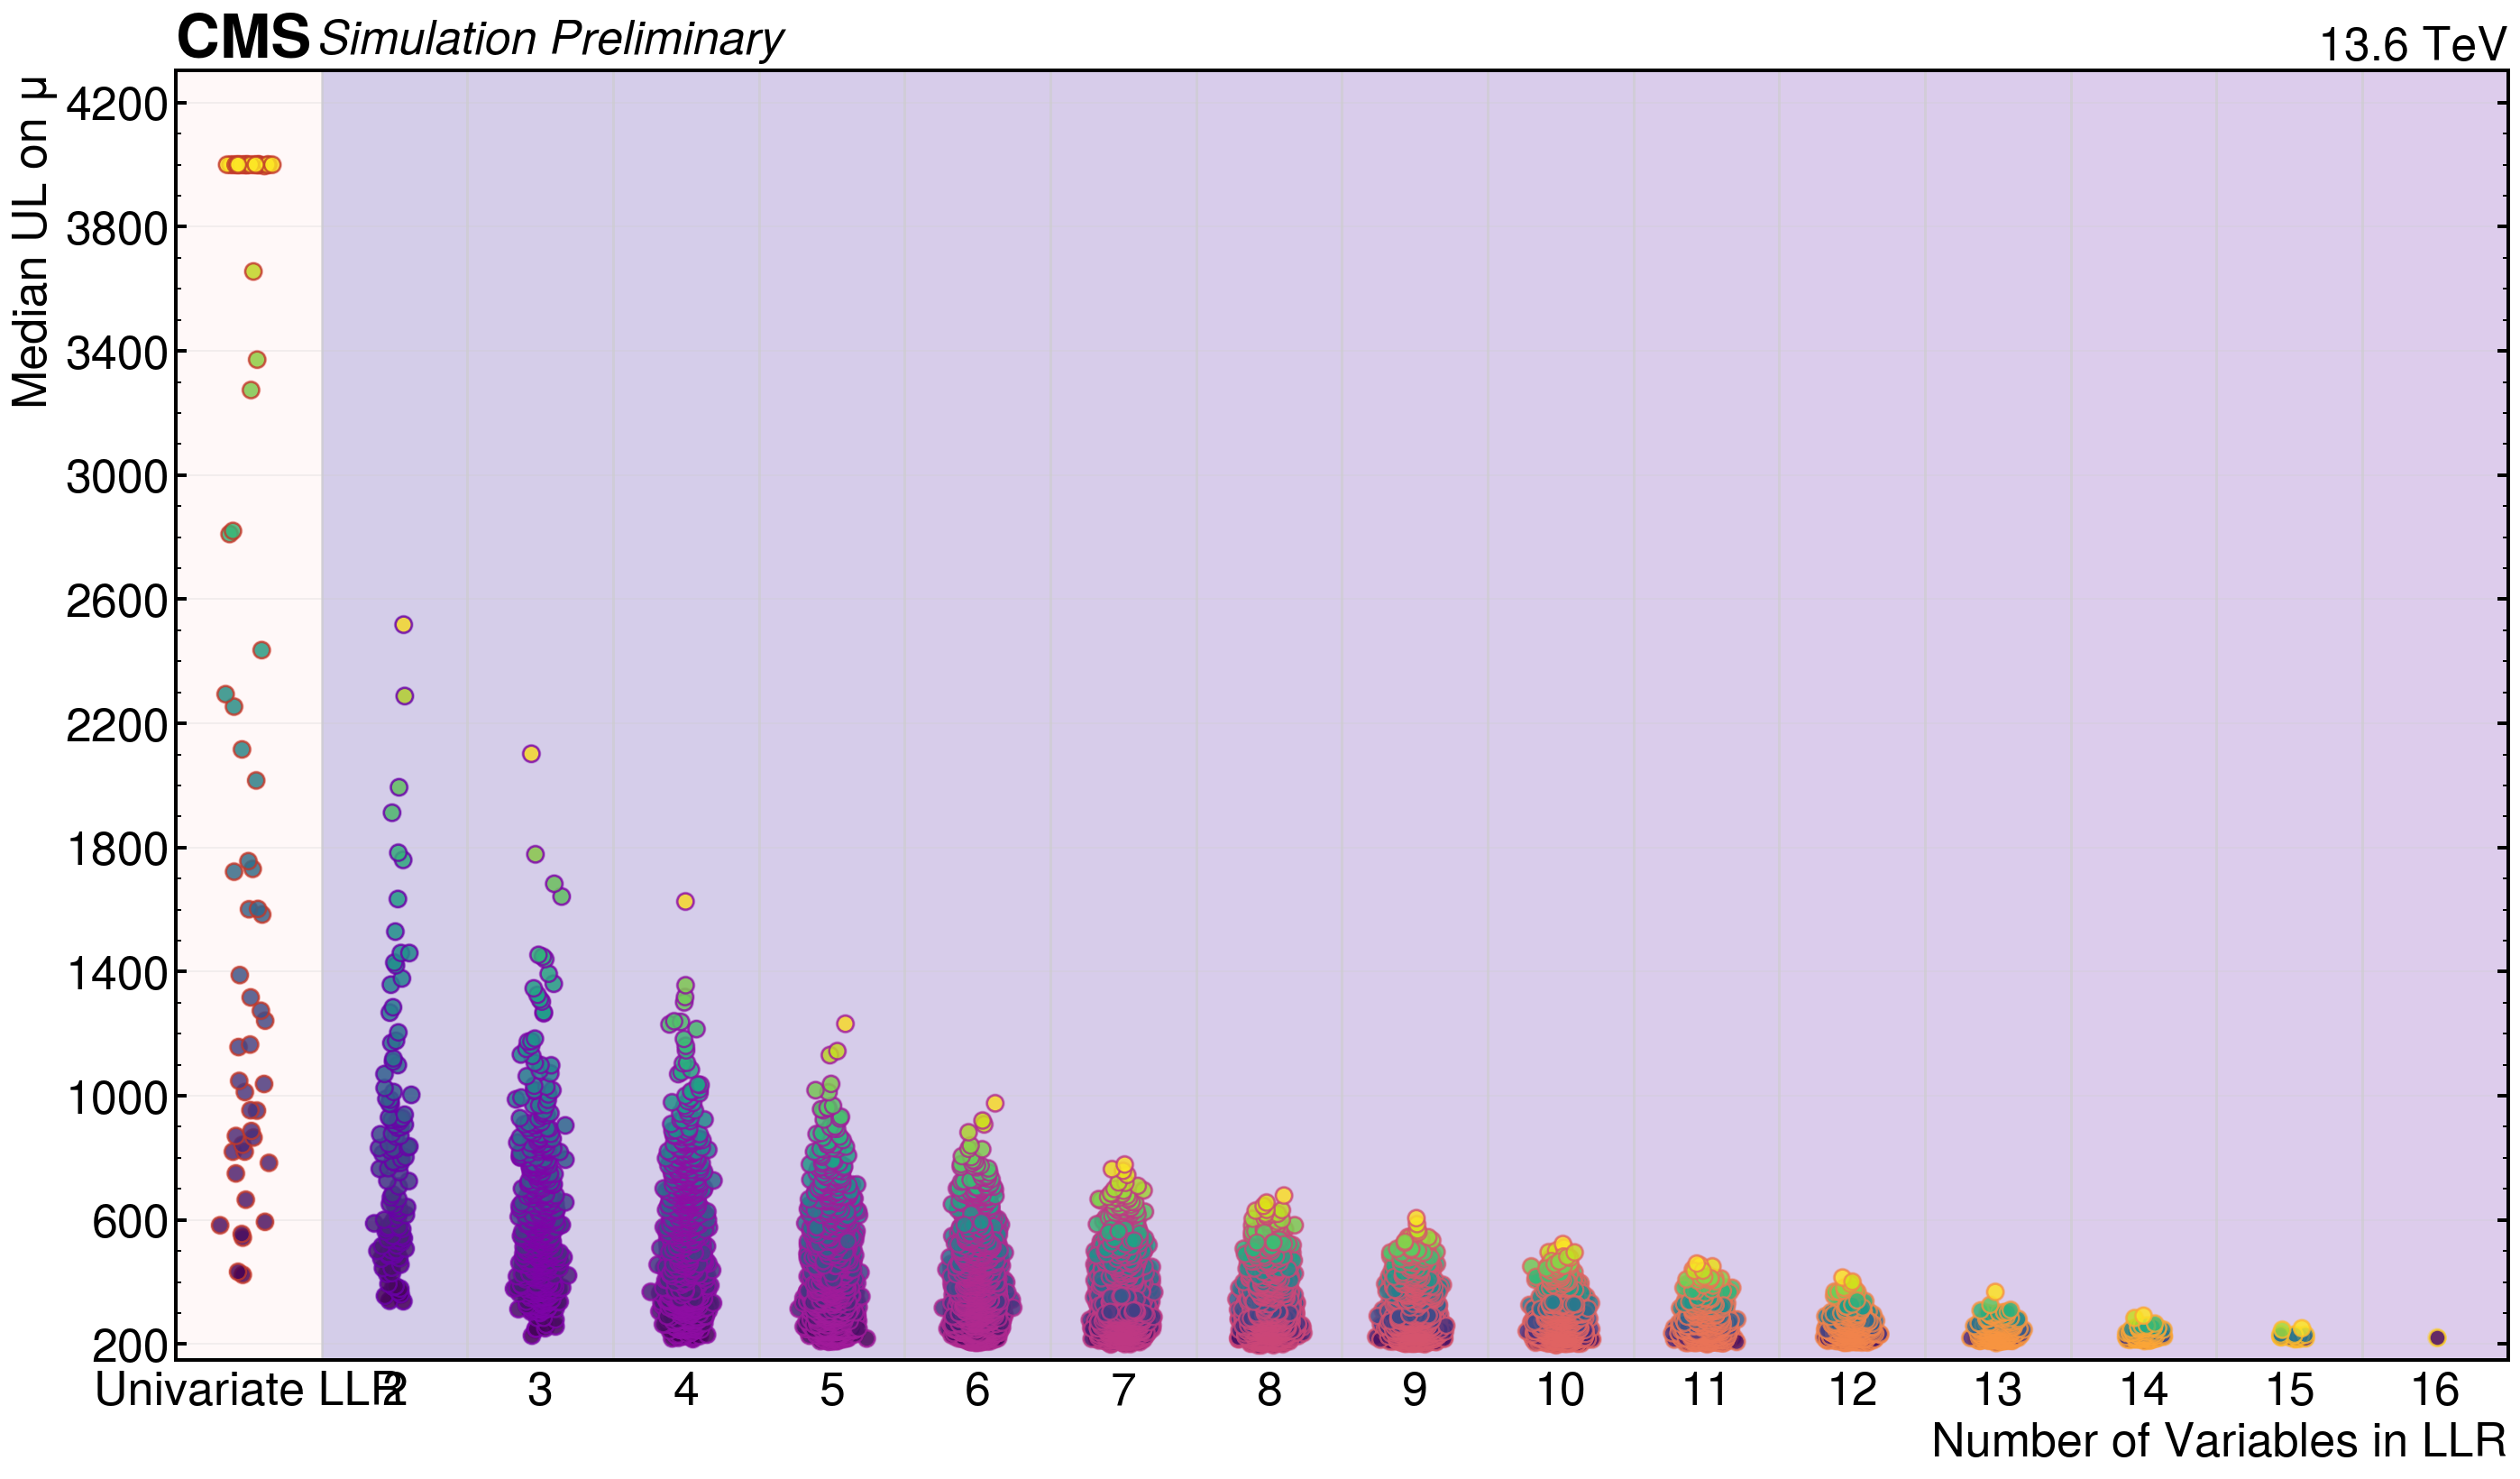

In [64]:
df_multivar = pd.concat([df_llrs_fact, df_from_1D])
scatterplot_UL_by_type(df_multivar, Path('llr_study') / 'llr_factorized_ULs.pdf')

CMS-style enhanced scatter plot saved to llr_study/llr_from_vars_ULs.pdf


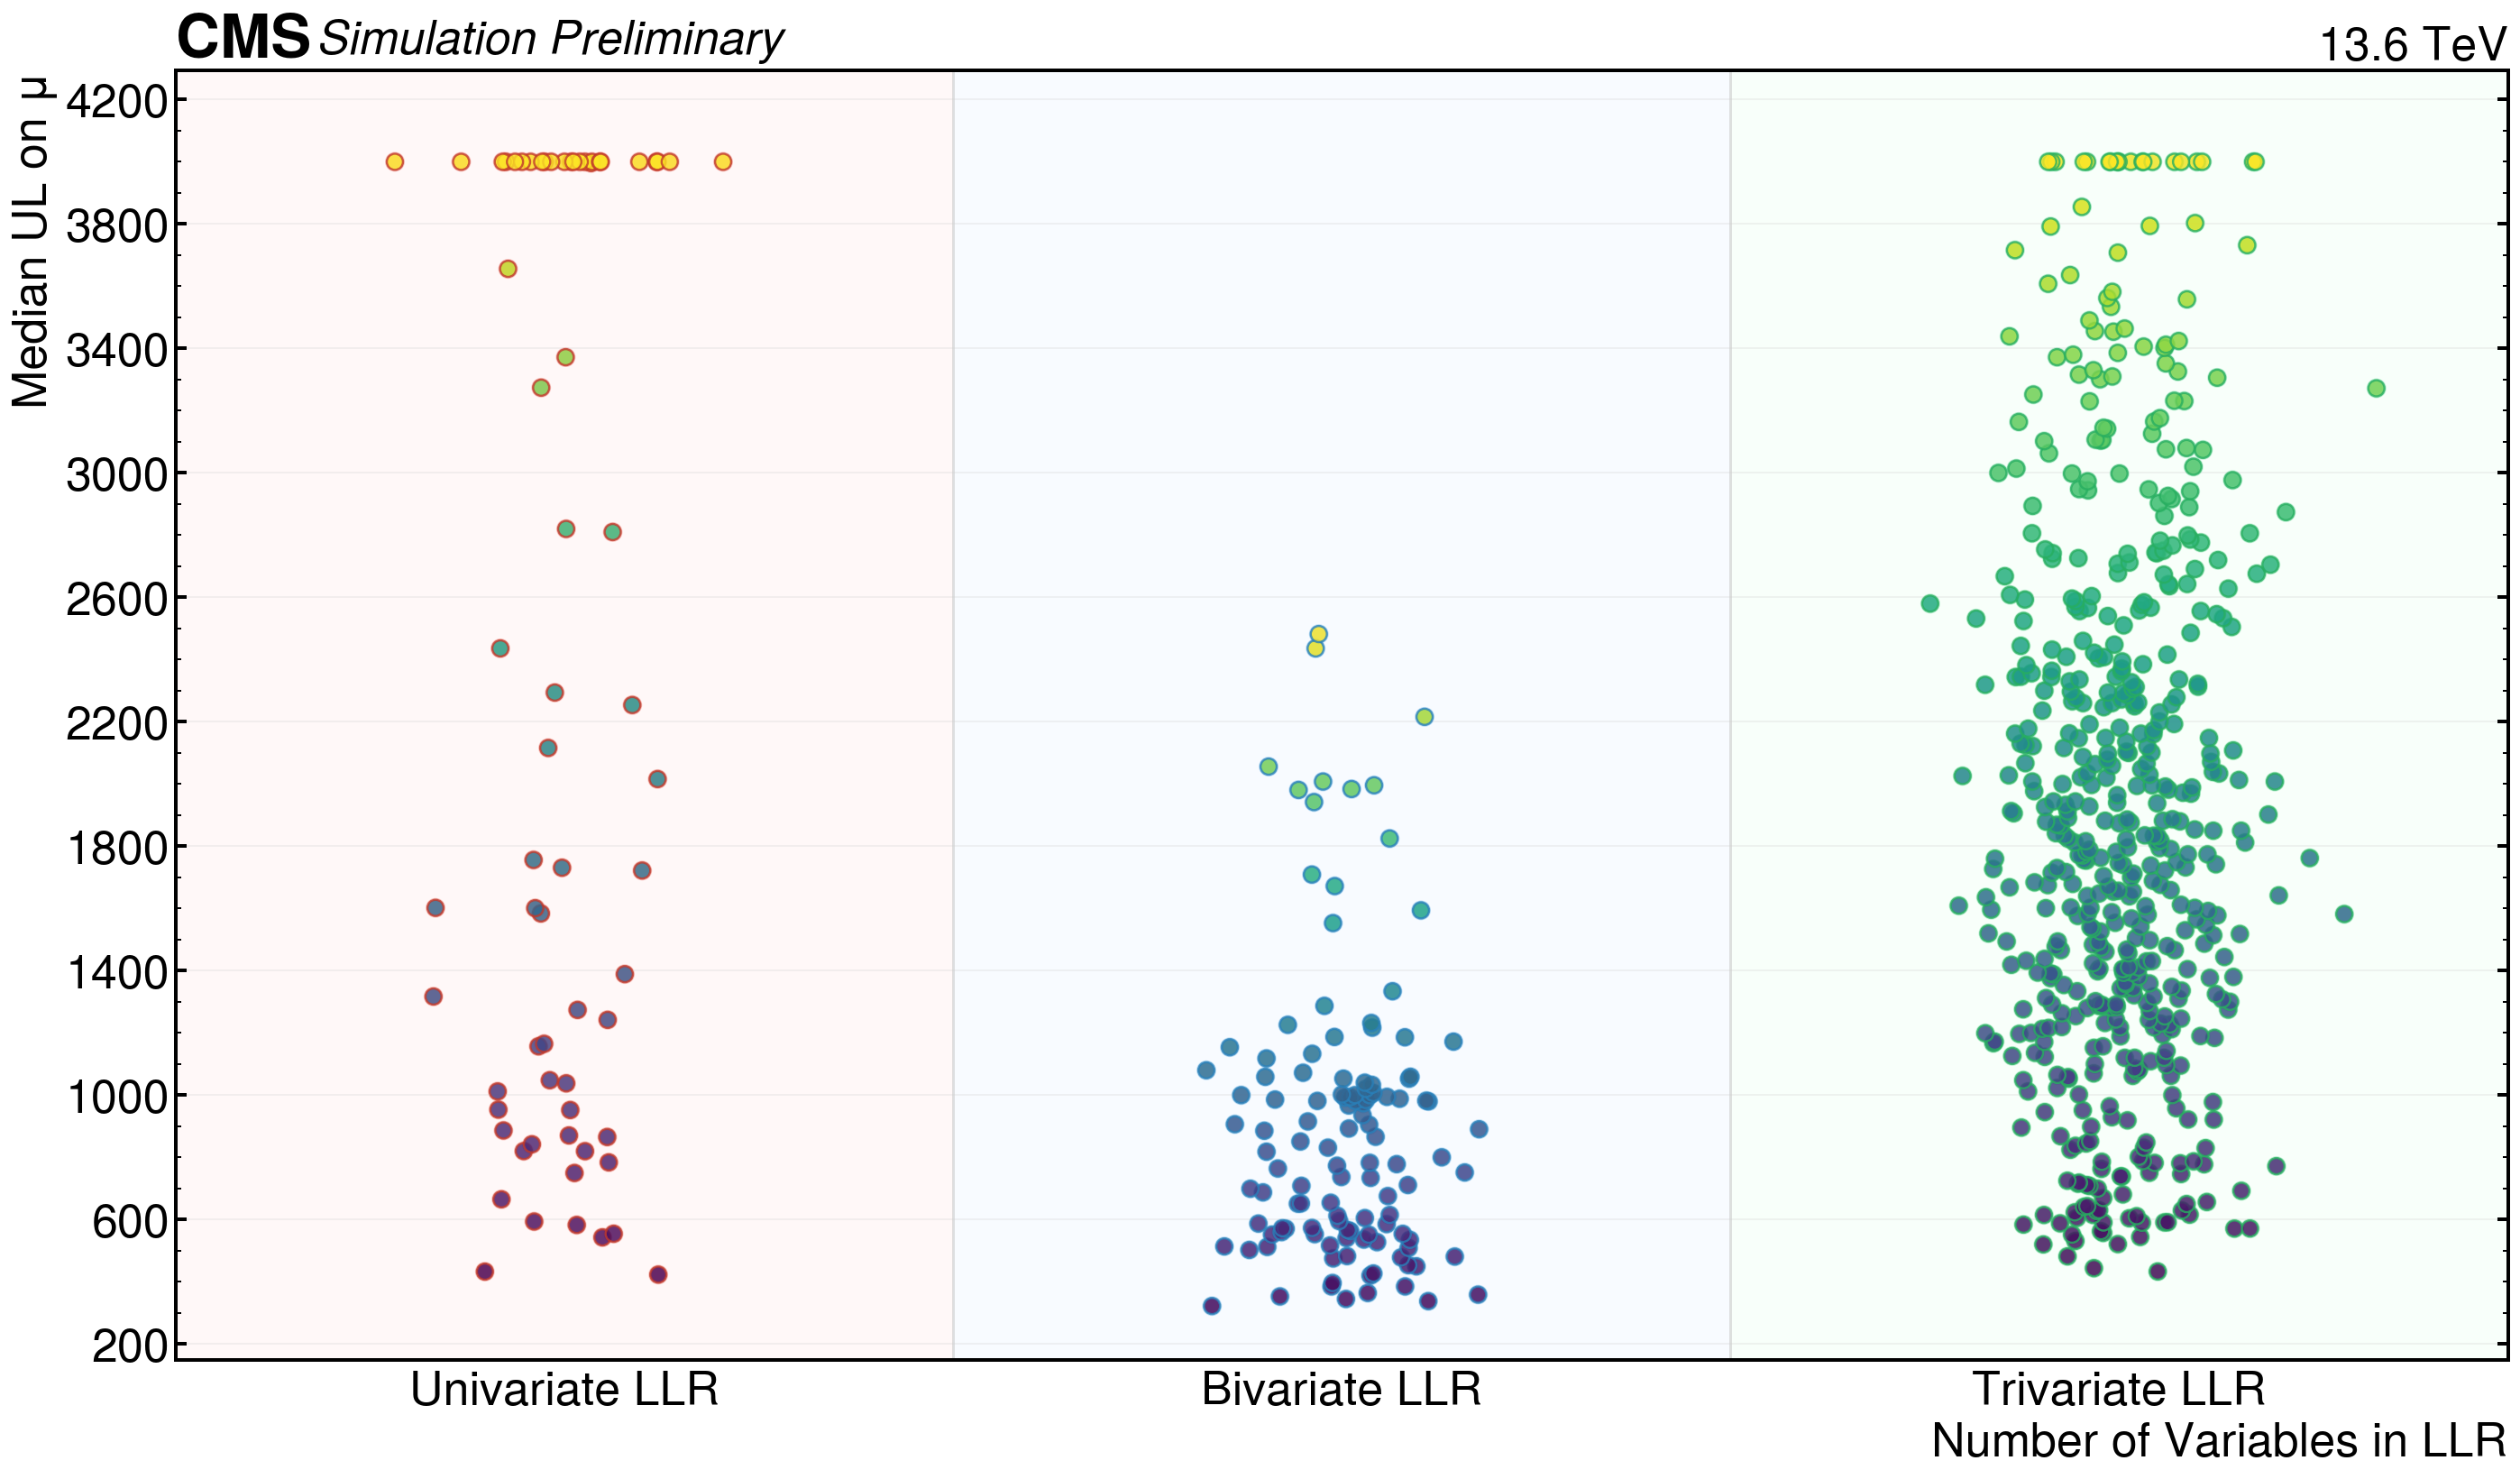

In [ ]:
scatterplot_UL_by_type(df_from_vars, Path('llr_study') / 'llr_from_vars_ULs.pdf')

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


CMS-style hierarchical plot saved to llr_study/all_llrs_from_1D.pdf


posx and posy should be finite values
posx and posy should be finite values


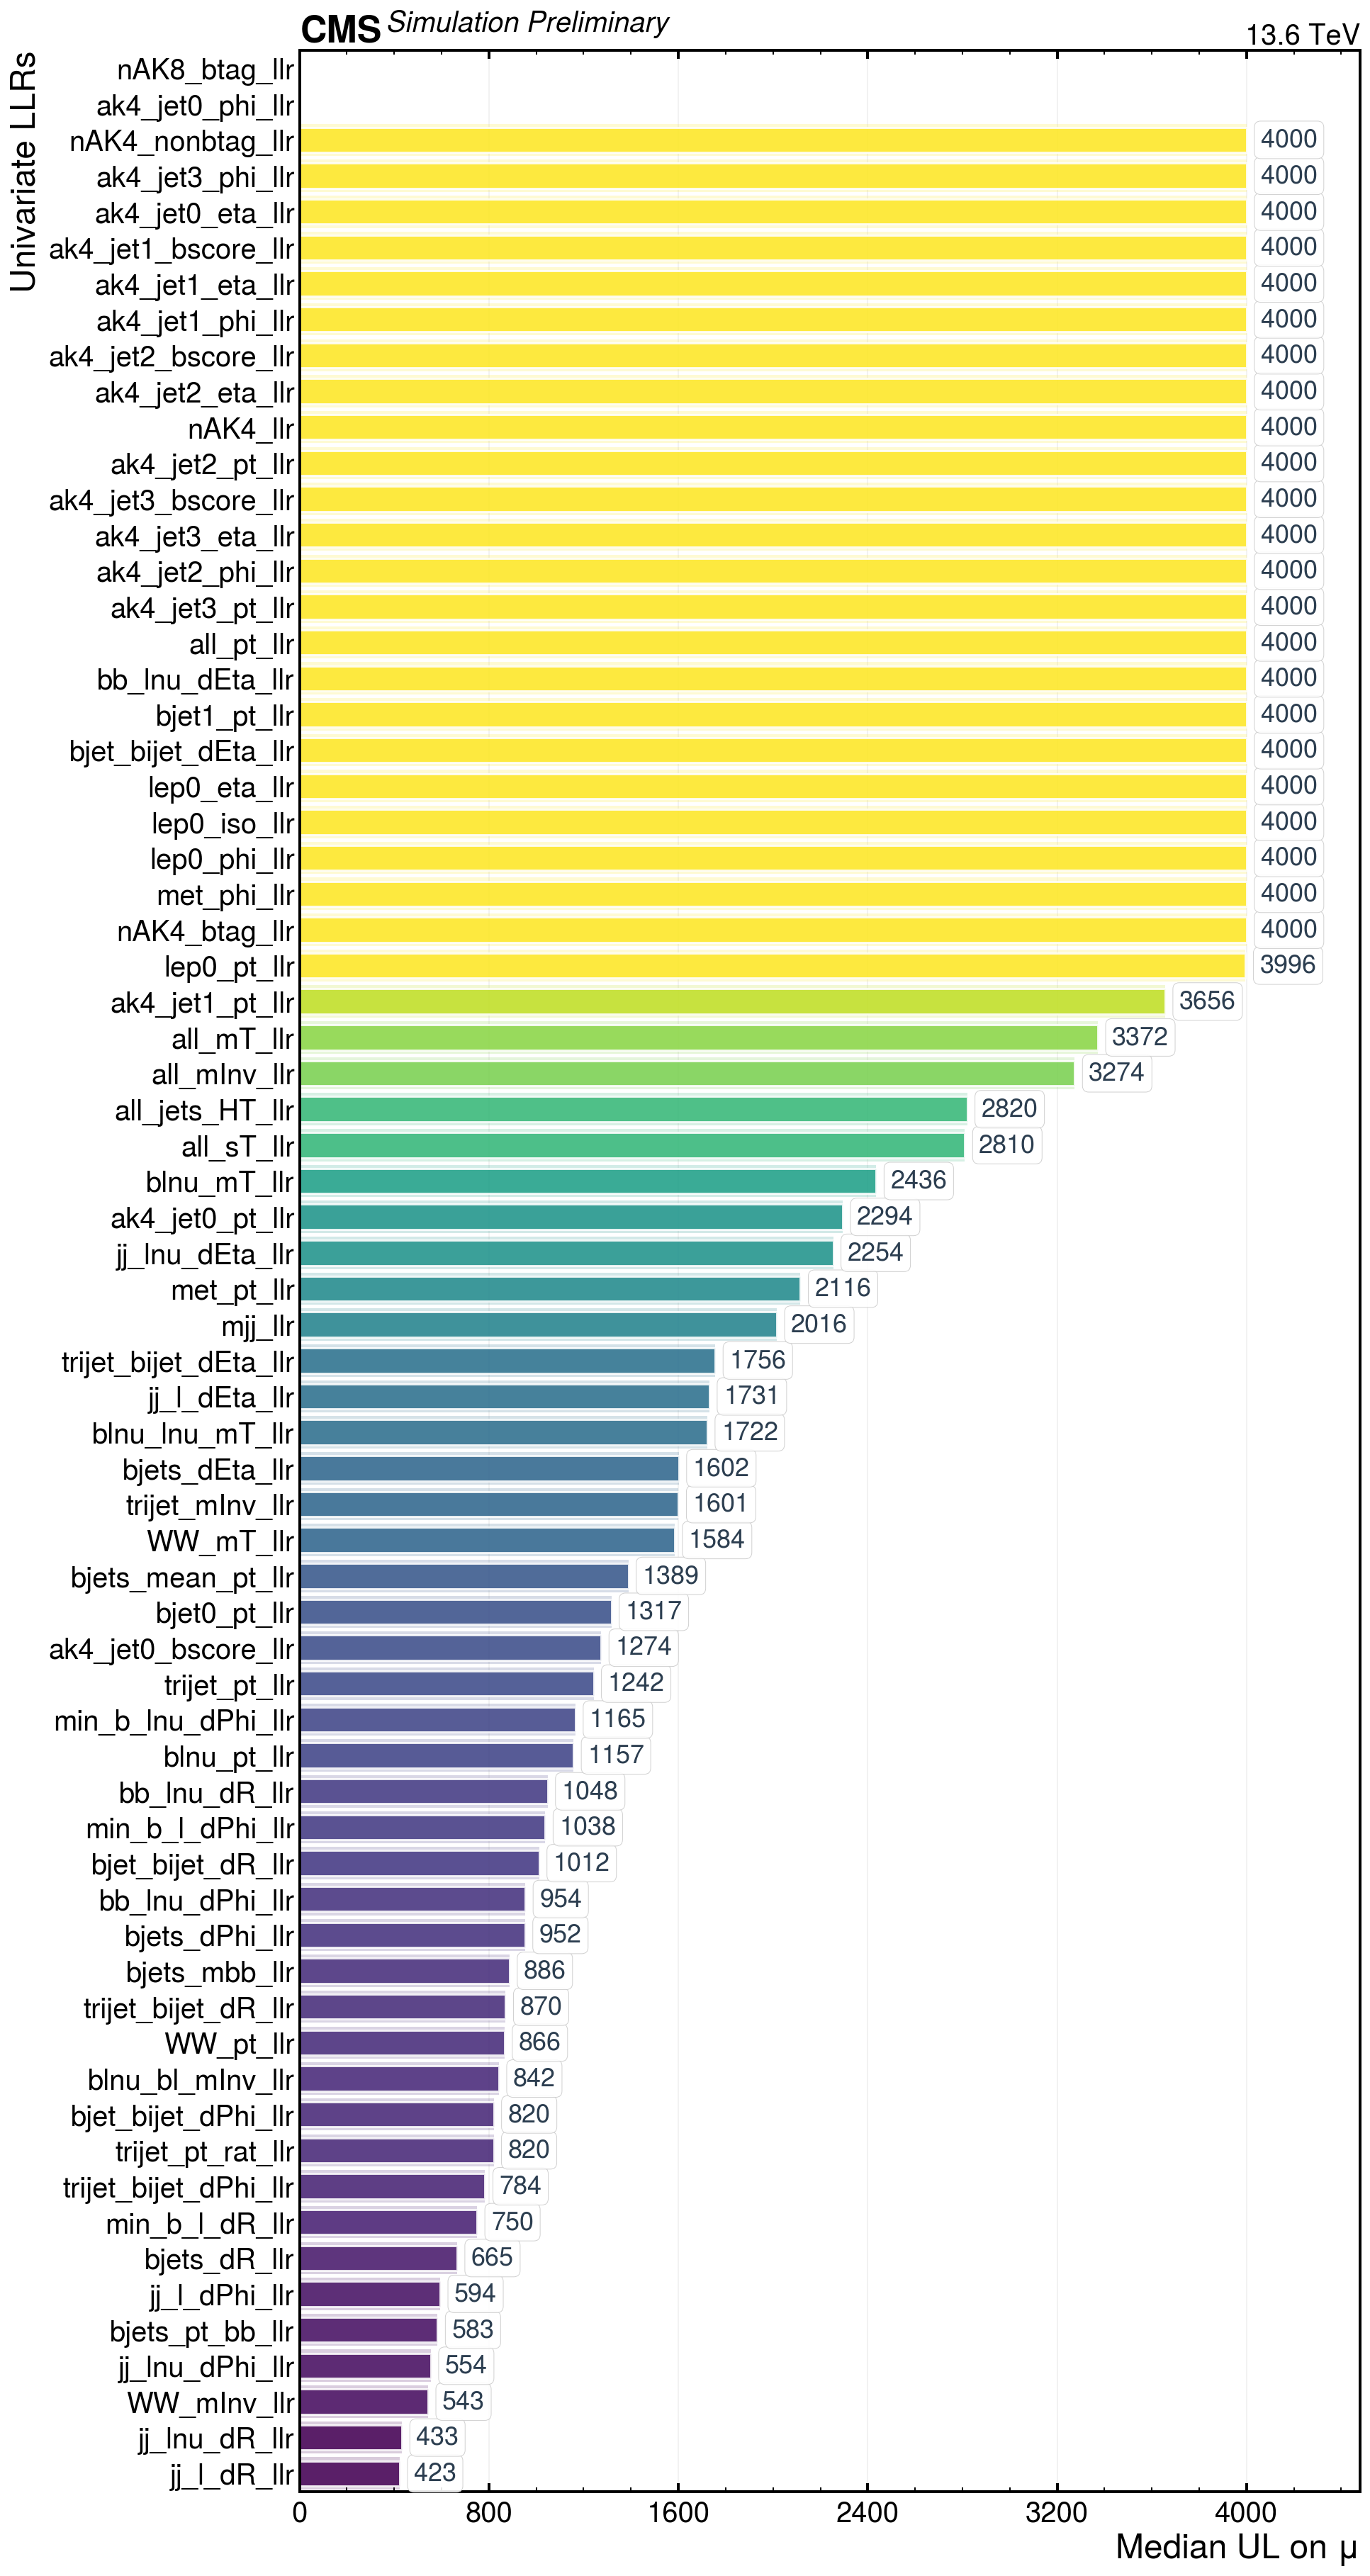

In [59]:
df_from_1D = df_from_1D.sort_values('mu', ascending=True).reset_index(drop=True)
outfile = Path('llr_study') / "all_llrs_from_1D.pdf"
hierarchical_UL_plot(df_from_1D, outfile=outfile , ylabel='Univariate LLRs')

CMS-style hierarchical plot saved to llr_study/top10_llrs_from_2D.pdf


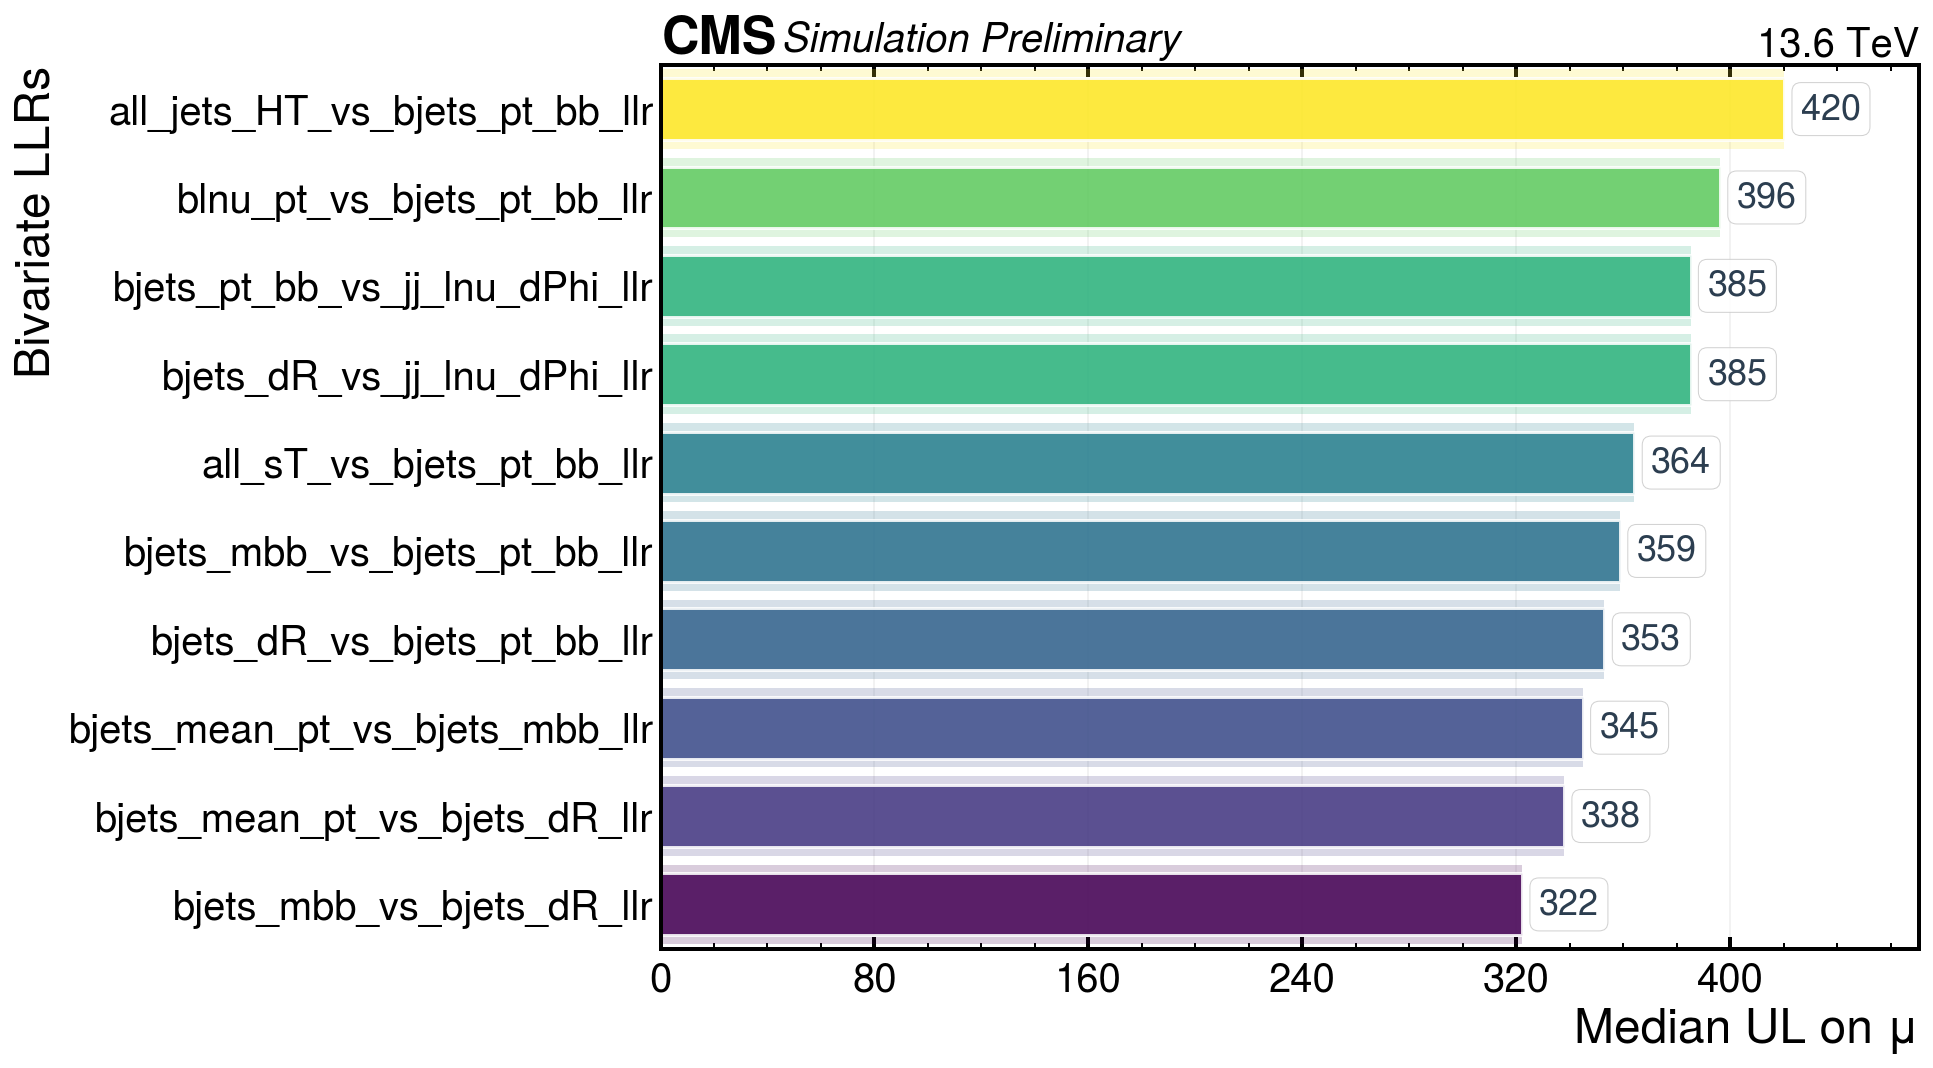

In [ ]:
df_from_2D = df_from_2D.sort_values('mu', ascending=True).reset_index(drop=True)
df_from_2D_top10 = df_from_2D.head(10)
outfile = Path('llr_study') / "top10_llrs_from_2D.pdf"
hierarchical_UL_plot(df_from_2D_top10, outfile=outfile , ylabel='Bivariate LLRs')

CMS-style hierarchical plot saved to llr_study/top10_llrs_from_3D.pdf


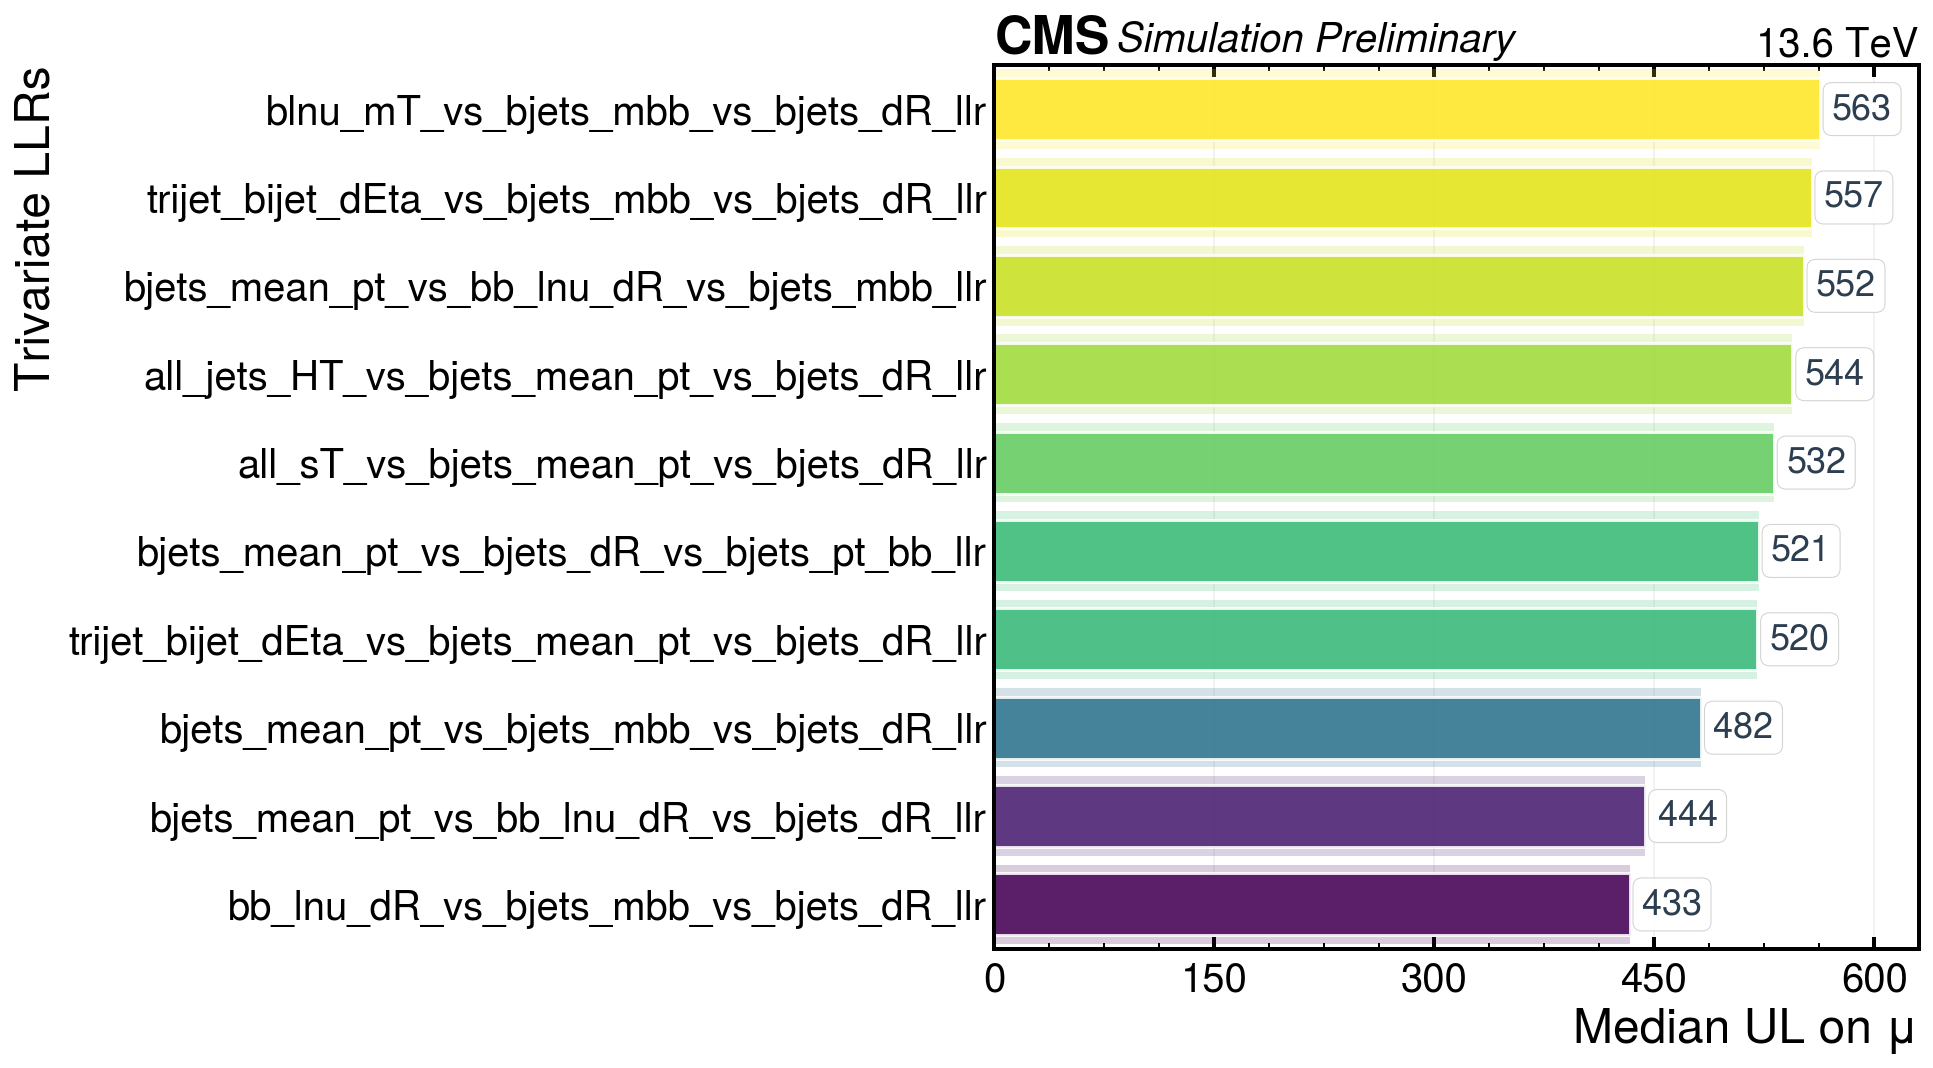

In [ ]:
df_from_3D = df_from_3D.sort_values('mu', ascending=True).reset_index(drop=True)
df_from_3D_top10 = df_from_3D.head(10)
outfile = Path('llr_study') / "top10_llrs_from_3D.pdf"
hierarchical_UL_plot(df_from_3D_top10, outfile=outfile , ylabel='Trivariate LLRs')

Saved to llr_study/trend_factorized_llrs.pdf


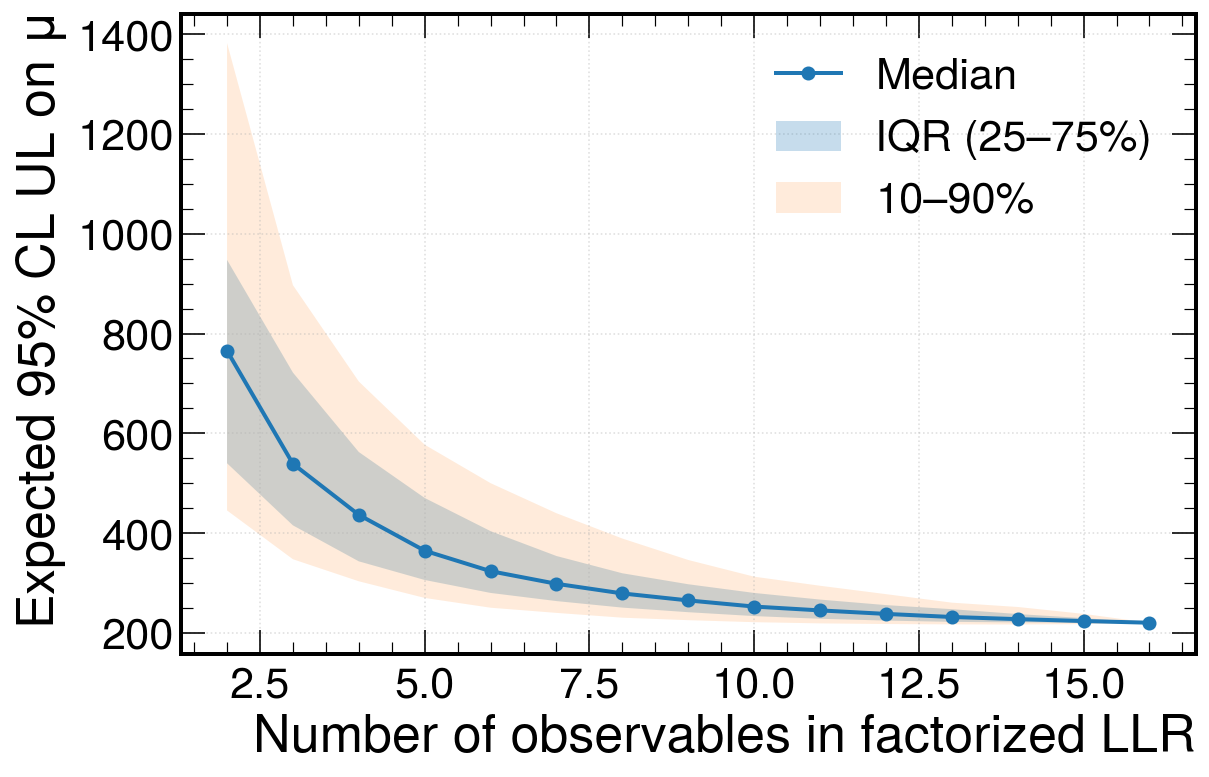

In [57]:
plot_llr_factorized_trend(df_llrs_fact, outfile = Path('llr_study') / "trend_factorized_llrs.pdf")

/cvmfs/sft.cern.ch/lcg/views/LCG_105/x86_64-el9-gcc11-opt/lib/python3.9/site-packages/matplotlib/lines.py:1205: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  neq = current != val


CMS-style enhanced boxplot saved to llr_study/llr_factorized_ULs_boxplot.pdf


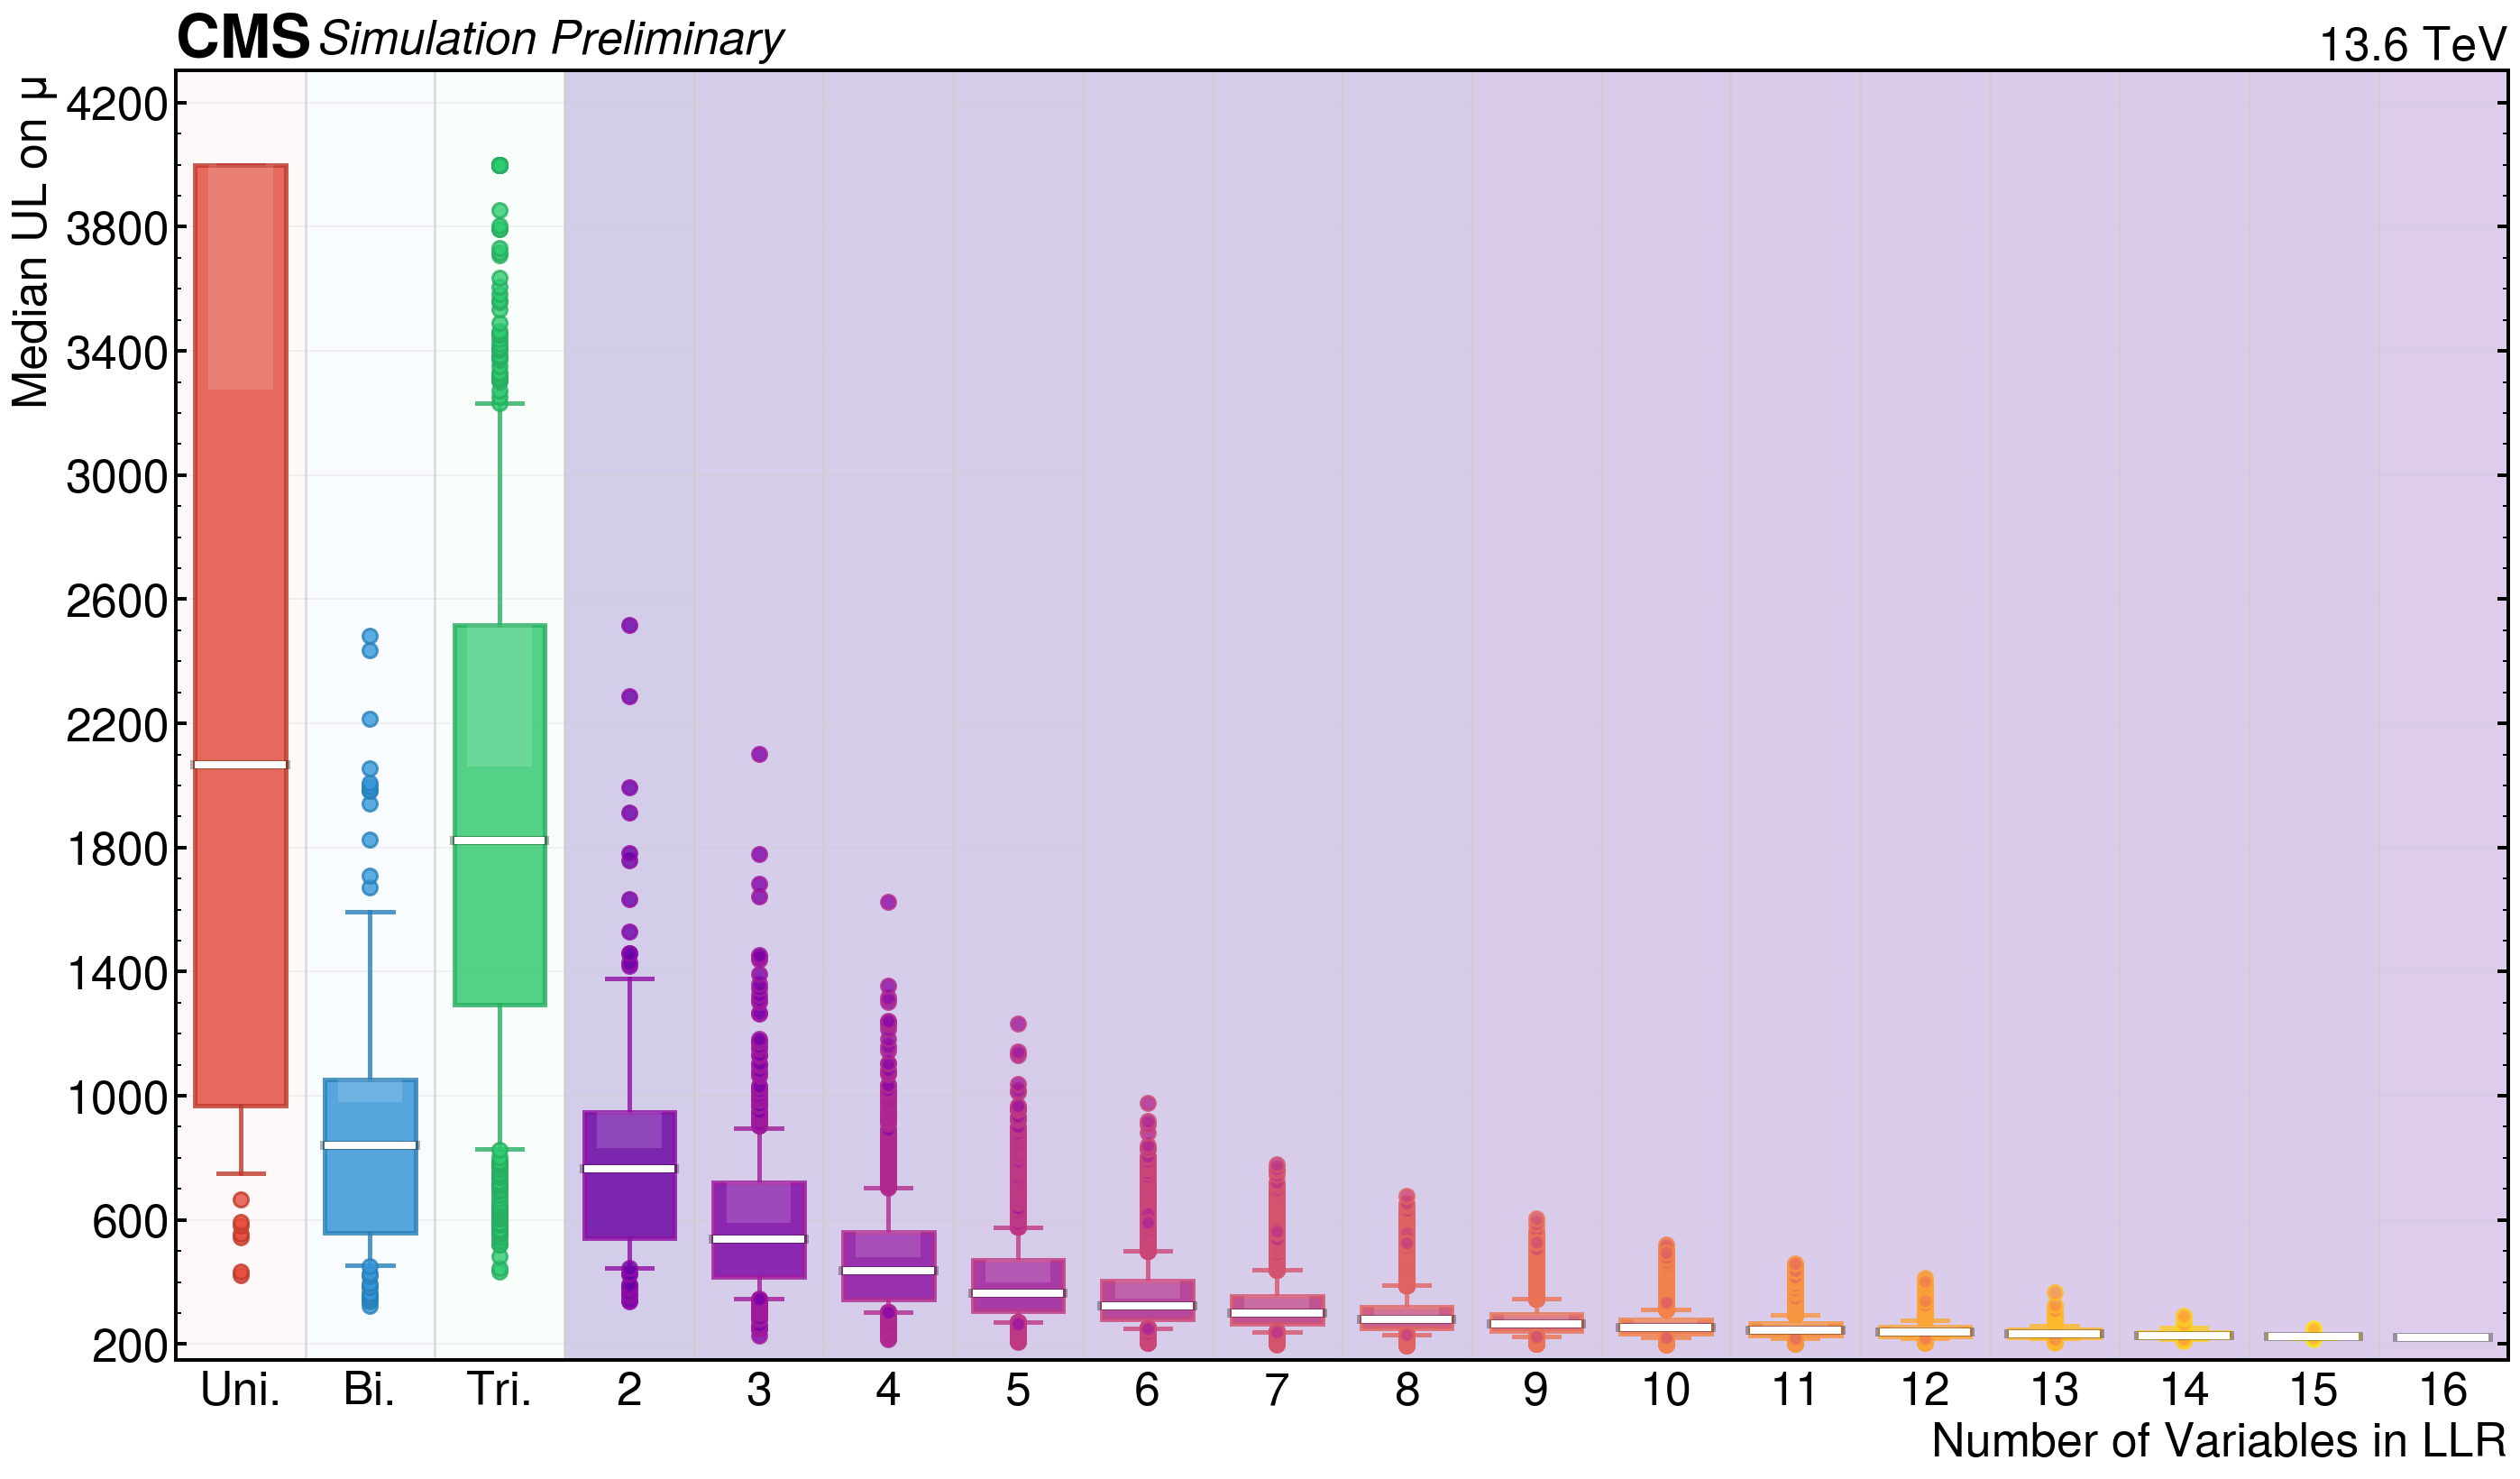

In [73]:
df_full = pd.concat([df_llrs_fact, df_from_vars])
boxplot_UL_by_type(df_full, Path('llr_study') / 'llr_factorized_ULs_boxplot.pdf')